In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load preprocessed dataset
df = pd.read_csv("secondary_data_preprocessed.csv")

In [3]:
X = df.drop(columns=["class_encoded"], errors="ignore")
y = df["class_encoded"]

In [7]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Model & Parameter Tuning
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}
grid_rf = GridSearchCV(rf, param_grid, cv=3)
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, 20, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 150]})

In [27]:
best_rf = grid_rf.best_estimator_
print("Best Parameters:", grid_rf.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}


In [29]:
# Evaluation
y_pred = best_rf.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7309833024118738
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.77      0.72      4850
           1       0.79      0.70      0.74      5930

    accuracy                           0.73     10780
   macro avg       0.73      0.73      0.73     10780
weighted avg       0.74      0.73      0.73     10780



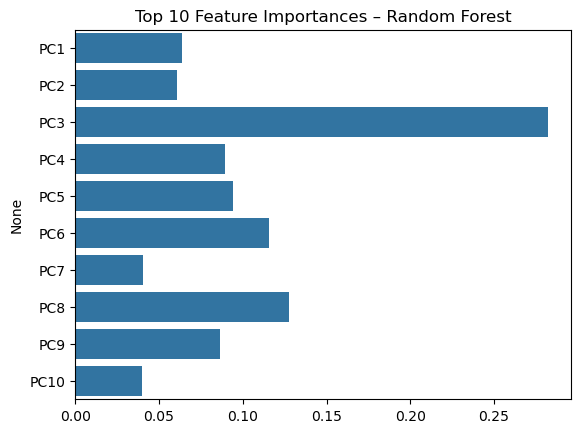

In [31]:
sns.barplot(x=best_rf.feature_importances_[:10], y=X.columns[:10])
plt.title("Top 10 Feature Importances – Random Forest")
plt.show()